In [1]:
#===========================================================
#Import Req Library
#===========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
#=============================================================================
#Load Auto MPG dataset
#=============================================================================

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)

#Display the First Five Row
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
#===========================================================
#Separate Input and Output
#===========================================================

X = df[['displacement']]
y = df['mpg']

#Check Missing values

print("Missing values in",X.isnull().sum())
print("Missing values in mpg:",y.isnull().sum())

Missing values in displacement    0
dtype: int64
Missing values in mpg: 0


In [4]:
#===========================================================
#Remove rows containing missing values
#===========================================================

data = df[['displacement','mpg']].dropna()

#Update input & output

X = data[['displacement']]
y = data['mpg']

#Display the selected data

print("Feature:")
print(X.head())

print("\n Target:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

 Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


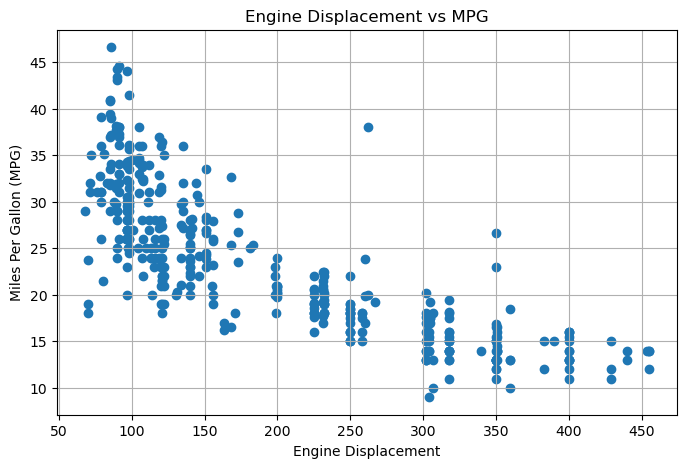

In [5]:
plt.figure(figsize=(8,5))

plt.scatter(X,y)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon (MPG)")
plt.title("Engine Displacement vs MPG")

plt.grid(True)
plt.show()

In [6]:
#===========================================================
# Split the dataset
#===========================================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 318
Testing samples: 80


In [7]:
# Create Linear Regression model

linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Predict on test data
y_pred_linear = linear_model.predict(X_test)

In [8]:
# Caculate MSE

mse_linear = mean_squared_error(y_test,y_pred_linear)

# Calculate R-squared
r2_linear = r2_score(y_test,y_pred_linear)

print("Linear Regression Results")
print("--------------------------------")
print("MSE:", mse_linear)
print("R-squared:", r2_linear)

Linear Regression Results
--------------------------------
MSE: 18.102543998358946
R-squared: 0.6633114869465595


In [9]:
# Store results
results = []

# Store polynomial models for plotting
polynomial_models = {}

# Add Linear Regression results
results.append(
    {'Model': 'Linear Regression',
     'Degree': 1,'MSE': mse_linear,
     'R-Squared': r2_linear
    })

# Try Polynomial degrees from 2 to 5
for degree in range(2, 6):

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    # Transform training and testing data
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Create Linear Regression model
    poly_model = LinearRegression()

    # Train polynomial regression model
    poly_model.fit(X_train_poly, y_train)

    # Make predictions
    y_pred_poly = poly_model.predict(X_test_poly)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred_poly)
    r2 = r2_score(y_test, y_pred_poly)

    # Store results
    results.append({
        'Model': 'Polynomial Regression',
        'Degree': degree,
        'MSE': mse,
        'R-Squared': r2
    })

    # Store model and polynomial transformer
    polynomial_models[degree] = {
        'poly': poly,
        'model': poly_model
    }

# Convert result into DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df

,Model,Degree,MSE,R-Squared
0,Linear Regression,1,18.102544,0.663311
1,Polynomial Regression,2,15.107354,0.719019
2,Polynomial Regression,3,14.943632,0.722064
3,Polynomial Regression,4,14.961487,0.721732
4,Polynomial Regression,5,15.230896,0.716721


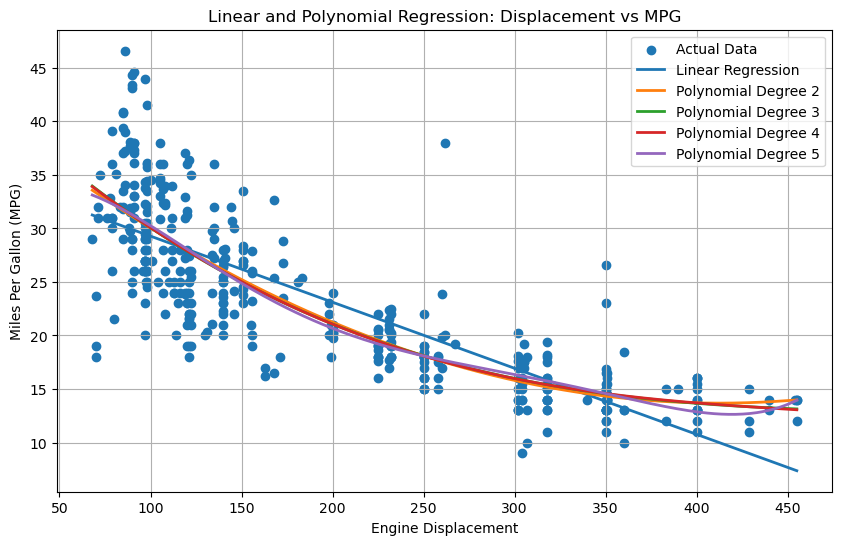

In [10]:
# Create smooth X values for plotting
X_plot = pd.DataFrame({
    'displacement': np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300
    )
})

# Create figure
plt.figure(figsize=(10, 6))

# Plot actual data
plt.scatter(
    X['displacement'],
    y,
    label='Actual Data',
)

# =======================================
# Plot Linear Regression

y_plot_linear = linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label='Linear Regression',
    linewidth=2
)

# ===========================================
# Plot Polynomial Regression (Degrees 2 to 5)
#============================================

for degree in range(2, 6):

    # Retrieve stored transformer and model
    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    # Transform smooth X values
    X_plot_poly = poly.transform(X_plot)

    # Predict
    y_plot_poly = poly_model.predict(X_plot_poly)

    # Plot polynomial curve
    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        label=f'Polynomial Degree {degree}',
        linewidth=2
    )

# =======================================
# Plot formatting
#=========================================

plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon (MPG)')
plt.title('Linear and Polynomial Regression: Displacement vs MPG')
plt.legend()
plt.grid(True)
plt.show()

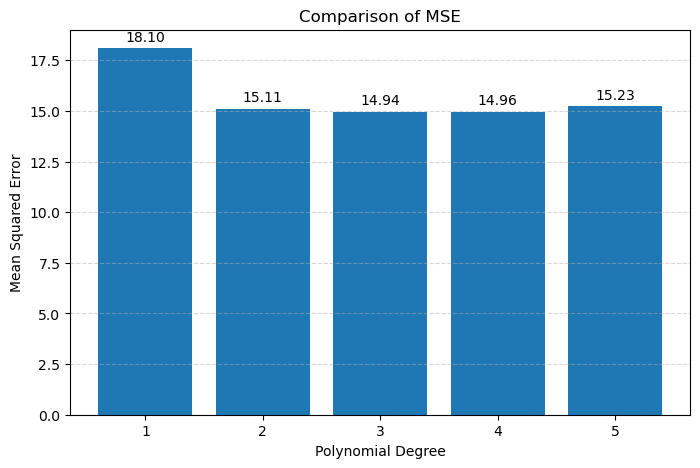

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

# Add labels above bars
plt.bar_label(bars, fmt='%.2f',padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

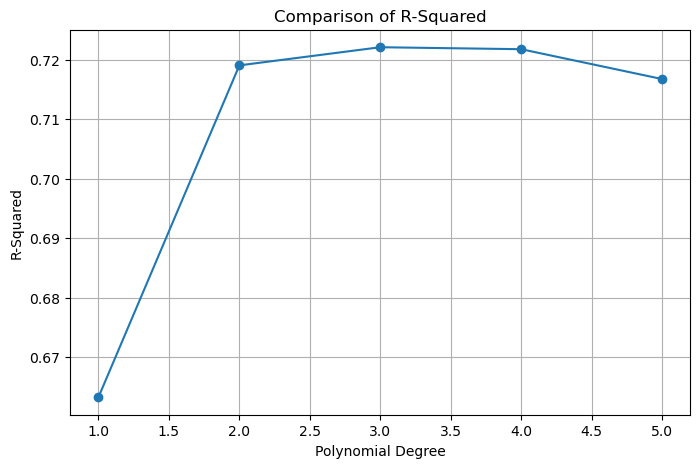

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['Degree'],
    results_df['R-Squared'],
    marker='o'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R-Squared")
plt.title("Comparison of R-Squared")
plt.grid(True)
plt.show()